# Underserved Intercity Air Routes: Final Project

## Research question

Which major-city air routes appear underserved after comparing observed flight supply with city population, destination tourism demand, and country-level economic capacity?

## Target audience

This analysis is for airline route planners and aviation analysts who need a screening tool for possible domestic and cross-border route opportunities. The goal is not to prove that a route should be launched immediately, but to identify candidate corridors that deserve deeper schedule, pricing, and operational research.

## Planned final-project enhancement

The midterm version used AviationStack flight records, OurAirports airport geography, WUP city population, and World Bank tourism indicators. The final version adds World Bank GDP data so the route score reflects economic capacity as well as population and tourism demand.


## Final Notebook Structure

1. Introduction and motivation
2. Load and clean flight, airport, population, tourism, and GDP data
3. Data quality checks
4. Merge datasets and engineer route-level features
5. EDA tables and charts
6. Models and metrics
7. Top underserved route recommendations
8. Conclusion, limitations, and future work

Use the midterm notebook as the code base, but keep this final notebook polished and remove raw exploratory output that does not support the story.


In [1]:
# Core imports.
import math
import os
import re
import sqlite3
import unicodedata
import warnings
from getpass import getpass
from pathlib import Path

warnings.filterwarnings("ignore", message="urllib3 v2 only supports OpenSSL.*")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)


## GDP Data Source

Use the downloaded World Bank country-level GDP file because it joins cleanly to the existing World Bank tourism data by ISO3 country code.

- Main file: `API_NY.GDP.MKTP.CD_DS2_en_csv_v2_252769.csv`
- Indicator: `NY.GDP.MKTP.CD`, GDP in current US dollars
- Country metadata: `Metadata_Country_API_NY.GDP.MKTP.CD_DS2_en_csv_v2_252769.csv`

The metadata file is used to remove World Bank regional aggregates, leaving country-level rows for the route analysis.


In [2]:
GDP_FILE = "API_NY.GDP.MKTP.CD_DS2_en_csv_v2_252769.csv"
GDP_COUNTRY_METADATA_FILE = "Metadata_Country_API_NY.GDP.MKTP.CD_DS2_en_csv_v2_252769.csv"
CLEAN_GDP_FILE = "data/country_gdp_current_usd_clean.csv"
GDP_RECENT_YEAR = 2023

os.makedirs("data", exist_ok=True)

gdp_raw = pd.read_csv(GDP_FILE, skiprows=4)
gdp_country_metadata = pd.read_csv(GDP_COUNTRY_METADATA_FILE)

# World Bank indicator downloads include regional aggregates; keep rows with a Region value to retain countries only.
actual_countries = gdp_country_metadata.loc[
    gdp_country_metadata["Region"].notna() & gdp_country_metadata["Region"].ne(""),
    ["Country Code", "Region", "IncomeGroup", "TableName"],
]

year_cols = [col for col in gdp_raw.columns if str(col).isdigit()]

gdp_long = gdp_raw.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_cols,
    var_name="year",
    value_name="gdp_current_usd",
)

gdp_long["year"] = pd.to_numeric(gdp_long["year"], errors="coerce").astype("Int64")
gdp_long["gdp_current_usd"] = pd.to_numeric(gdp_long["gdp_current_usd"], errors="coerce")

country_gdp = (
    gdp_long
    .dropna(subset=["gdp_current_usd"])
    .merge(actual_countries, on="Country Code", how="inner")
    .sort_values(["Country Code", "year"])
    .groupby("Country Code", as_index=False)
    .tail(1)
    .rename(columns={
        "Country Code": "country_iso3",
        "Country Name": "country_name",
        "Region": "wb_region",
        "IncomeGroup": "income_group",
        "year": "gdp_year",
        "Indicator Code": "indicator_code",
        "Indicator Name": "indicator_name",
    })
    [[
        "country_iso3", "country_name", "gdp_year", "gdp_current_usd",
        "wb_region", "income_group", "indicator_code", "indicator_name",
    ]]
    .reset_index(drop=True)
)

country_gdp.to_csv(CLEAN_GDP_FILE, index=False)

print(f"Raw World Bank GDP rows: {len(gdp_raw):,}")
print(f"Clean country GDP rows: {len(country_gdp):,}")
print(f"Most common GDP year: {int(country_gdp['gdp_year'].mode().iloc[0])}")
print(f"Countries with 2024 GDP: {(country_gdp['gdp_year'] == 2024).sum():,}")

country_gdp.head()

Raw World Bank GDP rows: 266
Clean country GDP rows: 214
Most common GDP year: 2024
Countries with 2024 GDP: 192


,country_iso3,country_name,gdp_year,gdp_current_usd,wb_region,income_group,indicator_code,indicator_name
0,ABW,Aruba,2024,4.265651e+09,Latin America & Caribbean,High income,NY.GDP.MKTP.CD,GDP (current US$)
1,AFG,Afghanistan,2023,1.715223e+10,Middle East & North Africa,Low income,NY.GDP.MKTP.CD,GDP (current US$)
2,AGO,Angola,2024,1.009989e+11,Sub-Saharan Africa,Lower middle income,NY.GDP.MKTP.CD,GDP (current US$)
3,ALB,Albania,2024,2.704643e+10,Europe & Central Asia,Upper middle income,NY.GDP.MKTP.CD,GDP (current US$)
4,AND,Andorra,2024,4.039842e+09,Europe & Central Asia,High income,NY.GDP.MKTP.CD,GDP (current US$)


In [3]:
gdp_quality_summary = pd.DataFrame({
    "check": [
        "countries in cleaned GDP file",
        "missing GDP values",
        "duplicate ISO3 country codes",
        "minimum GDP year",
        "maximum GDP year",
        "countries using 2024 GDP",
    ],
    "value": [
        len(country_gdp),
        country_gdp["gdp_current_usd"].isna().sum(),
        country_gdp["country_iso3"].duplicated().sum(),
        int(country_gdp["gdp_year"].min()),
        int(country_gdp["gdp_year"].max()),
        int((country_gdp["gdp_year"] == 2024).sum()),
    ],
})

gdp_quality_summary

,check,value
0,countries in cleaned GDP file,214
1,missing GDP values,0
2,duplicate ISO3 country codes,0
3,minimum GDP year,2011
4,maximum GDP year,2024
5,countries using 2024 GDP,192


## Build The Route Analysis Dataset

This section loads the midterm data sources, adds GDP, and rebuilds the route-level table used for EDA, modeling, and SQL. Flight data is cached after the first API pull so the notebook can be rerun without repeatedly calling AviationStack.

In [4]:
AVIATIONSTACK_URL = "http://api.aviationstack.com/v1/flights"
FLIGHTS_CACHE = DATA_DIR / "aviationstack_flights_cached.csv"
TOURISM_CACHE = DATA_DIR / "world_bank_tourism_cached.csv"
MAX_FLIGHT_RECORDS = 500
LIMIT = 100
WUP_CITY_FILE = "WUP2025-F18-DEGURBA-100_Largest_Cities.xlsx"
WUP_YEAR = 2025
WORLD_BANK_BASE = "https://api.worldbank.org/v2"


def safe_nested(record, *keys):
    current = record
    for key in keys:
        if not isinstance(current, dict):
            return None
        current = current.get(key)
    return current


def fetch_aviationstack_flights(api_key, limit=100, max_records=500):
    flights = []
    offset = 0
    total_available = None

    while True:
        params = {"access_key": api_key, "limit": limit, "offset": offset}
        response = requests.get(AVIATIONSTACK_URL, params=params, timeout=30)
        response.raise_for_status()
        payload = response.json()
        if "error" in payload:
            raise RuntimeError(payload["error"])

        batch = payload.get("data", [])
        pagination = payload.get("pagination", {})
        total_available = pagination.get("total", total_available)
        if not batch:
            break

        for flight in batch:
            flights.append({
                "flight_date": flight.get("flight_date"),
                "flight_status": flight.get("flight_status"),
                "flight_iata": safe_nested(flight, "flight", "iata"),
                "flight_number": safe_nested(flight, "flight", "number"),
                "airline": safe_nested(flight, "airline", "name"),
                "dep_airport": safe_nested(flight, "departure", "airport"),
                "dep_iata": safe_nested(flight, "departure", "iata"),
                "dep_timezone": safe_nested(flight, "departure", "timezone"),
                "arr_airport": safe_nested(flight, "arrival", "airport"),
                "arr_iata": safe_nested(flight, "arrival", "iata"),
                "arr_timezone": safe_nested(flight, "arrival", "timezone"),
            })

        offset += limit
        hit_configured_cap = max_records is not None and len(flights) >= max_records
        hit_api_total = total_available is not None and offset >= total_available
        if hit_configured_cap or hit_api_total:
            break

    flights_df = pd.DataFrame(flights)
    return flights_df.head(max_records) if max_records is not None else flights_df


if FLIGHTS_CACHE.exists():
    flights_df = pd.read_csv(FLIGHTS_CACHE)
else:
    api_key = os.getenv("AVIATIONSTACK_API_KEY")
    if not api_key:
        api_key = getpass("Paste your AviationStack API key: ")
    flights_df = fetch_aviationstack_flights(api_key, LIMIT, MAX_FLIGHT_RECORDS)
    flights_df.to_csv(FLIGHTS_CACHE, index=False)

flights_df["dep_iata"] = flights_df["dep_iata"].str.upper().str.strip()
flights_df["arr_iata"] = flights_df["arr_iata"].str.upper().str.strip()

# Airport geography.
airports_raw = pd.read_csv("airports.csv", keep_default_na=False)
airport_cols = ["iata_code", "name", "type", "municipality", "iso_country", "continent", "latitude_deg", "longitude_deg"]
airports = (
    airports_raw.loc[:, airport_cols]
    .rename(columns={
        "iata_code": "iata",
        "name": "airport_name",
        "municipality": "airport_city",
        "iso_country": "country_code",
    })
    .query("iata != ''")
    .copy()
)
airports["iata"] = airports["iata"].str.upper().str.strip()
airports["country_code"] = airports["country_code"].str.upper().str.strip()
airports["latitude_deg"] = pd.to_numeric(airports["latitude_deg"], errors="coerce")
airports["longitude_deg"] = pd.to_numeric(airports["longitude_deg"], errors="coerce")
airports["airport_city"] = airports["airport_city"].fillna("Unknown")
type_rank = {"large_airport": 0, "medium_airport": 1, "small_airport": 2}
airports["type_rank"] = airports["type"].map(type_rank).fillna(9)
airports = airports.sort_values(["iata", "type_rank"]).drop_duplicates("iata", keep="first").drop(columns="type_rank")

# WUP top-100 city population.
wup_raw = pd.read_excel(WUP_CITY_FILE, sheet_name="Data", engine="openpyxl")
wup_cities = wup_raw[wup_raw["Year"].eq(WUP_YEAR)].copy()
wup_cities = wup_cities.rename(columns={
    "ISO2_Code": "country_code",
    "ISO2_code": "country_code",
    "ISO3_Code": "country_iso3",
    "ISO3_code": "country_iso3",
    "Location": "country_name",
    "Country_or_area": "country_name",
    "City_Name": "wup_city",
    "PWCent_Latitude": "wup_latitude",
    "PWCent_Longitude": "wup_longitude",
    "Population": "city_population_thousands",
})
wup_cities["country_code"] = wup_cities["country_code"].str.upper().str.strip()
wup_cities["city_population"] = wup_cities["city_population_thousands"] * 1000
wup_cities = wup_cities[[
    "country_code", "country_iso3", "country_name", "wup_city", "Rank_Order",
    "wup_latitude", "wup_longitude", "city_population", "Pop_plausibility", "Land_area_km2",
]]


def fetch_world_bank(path, params=None):
    params = {"format": "json", "per_page": 20000, **(params or {})}
    response = requests.get(f"{WORLD_BANK_BASE}/{path}", params=params, timeout=120)
    response.raise_for_status()
    payload = response.json()
    if not isinstance(payload, list) or len(payload) < 2:
        raise ValueError(f"Unexpected World Bank response: {payload}")
    metadata, rows = payload[0], payload[1]
    pages = int(metadata.get("pages", 1))
    all_rows = rows
    for page in range(2, pages + 1):
        page_params = {**params, "page": page}
        page_response = requests.get(f"{WORLD_BANK_BASE}/{path}", params=page_params, timeout=120)
        page_response.raise_for_status()
        all_rows.extend(page_response.json()[1])
    return all_rows


def fetch_world_bank_indicator(indicator_code, value_name, start_year=2014, end_year=2024):
    rows = fetch_world_bank(f"country/all/indicator/{indicator_code}", {"date": f"{start_year}:{end_year}"})
    indicator_df = pd.DataFrame({
        "country_iso3": row.get("countryiso3code"),
        "wb_country_name": (row.get("country") or {}).get("value"),
        "year": pd.to_numeric(row.get("date"), errors="coerce"),
        value_name: row.get("value"),
    } for row in rows)
    indicator_df[value_name] = pd.to_numeric(indicator_df[value_name], errors="coerce")
    indicator_df = indicator_df.dropna(subset=["country_iso3", value_name]).sort_values(["country_iso3", "year"])
    most_recent = indicator_df.groupby("country_iso3", as_index=False).tail(1)
    return most_recent.rename(columns={"year": f"{value_name}_year"}).reset_index(drop=True)


if TOURISM_CACHE.exists():
    tourism = pd.read_csv(TOURISM_CACHE)
else:
    countries = pd.DataFrame({
        "country_code": row.get("iso2Code"),
        "country_iso3": row.get("id"),
        "wb_country_name": row.get("name"),
        "wb_region": (row.get("region") or {}).get("value"),
        "income_level": (row.get("incomeLevel") or {}).get("value"),
    } for row in fetch_world_bank("country"))
    tourism_arrivals = fetch_world_bank_indicator("ST.INT.ARVL", "tourism_arrivals")
    tourism_receipts = fetch_world_bank_indicator("ST.INT.RCPT.CD", "tourism_receipts_usd")
    tourism = (
        countries
        .merge(tourism_arrivals.drop(columns="wb_country_name"), on="country_iso3", how="left")
        .merge(tourism_receipts.drop(columns="wb_country_name"), on="country_iso3", how="left")
    )
    tourism.to_csv(TOURISM_CACHE, index=False)


def normalize_name(value):
    if pd.isna(value):
        return ""
    text = str(value).lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"\([^)]*\)", " ", text)
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def haversine_km(lat1, lon1, lat2, lon2):
    radius = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    d_phi = math.radians(lat2 - lat1)
    d_lambda = math.radians(lon2 - lon1)
    a = math.sin(d_phi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(d_lambda / 2) ** 2
    return radius * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def match_airport_to_nearest_wup_city(airports_df, wup_df, max_distance_km=250):
    matches = []
    wup_by_country = {country: group.copy() for country, group in wup_df.groupby("country_code")}
    for _, airport in airports_df.dropna(subset=["latitude_deg", "longitude_deg", "country_code"]).iterrows():
        candidates = wup_by_country.get(airport["country_code"])
        if candidates is None or candidates.empty:
            continue
        distances = candidates.apply(
            lambda city: haversine_km(
                float(airport["latitude_deg"]), float(airport["longitude_deg"]),
                float(city["wup_latitude"]), float(city["wup_longitude"]),
            ),
            axis=1,
        )
        best_idx = distances.idxmin()
        best_city = candidates.loc[best_idx]
        best_distance = distances.loc[best_idx]
        if best_distance <= max_distance_km:
            matches.append({
                "iata": airport["iata"],
                "airport_name": airport["airport_name"],
                "airport_city": airport["airport_city"],
                "airport_country_code": airport["country_code"],
                "airport_continent": airport["continent"],
                "airport_latitude": airport["latitude_deg"],
                "airport_longitude": airport["longitude_deg"],
                "country_code": best_city["country_code"],
                "country_iso3": best_city["country_iso3"],
                "country_name": best_city["country_name"],
                "wup_city": best_city["wup_city"],
                "wup_city_norm": normalize_name(best_city["wup_city"]),
                "city_population": best_city["city_population"],
                "city_rank": best_city["Rank_Order"],
                "wup_latitude": best_city["wup_latitude"],
                "wup_longitude": best_city["wup_longitude"],
                "airport_to_wup_city_km": best_distance,
                "pop_plausibility": best_city["Pop_plausibility"],
            })
    return pd.DataFrame(matches)


airport_city_matches = match_airport_to_nearest_wup_city(airports, wup_cities, max_distance_km=250)

# Merge flights to city endpoints, tourism, and GDP.
endpoint_cols = [
    "iata", "airport_name", "airport_city", "airport_country_code", "airport_continent",
    "airport_latitude", "airport_longitude", "country_code", "country_iso3", "country_name",
    "wup_city", "city_population", "city_rank", "airport_to_wup_city_km",
]
dep_endpoints = airport_city_matches[endpoint_cols].add_prefix("dep_").rename(columns={"dep_iata": "dep_iata"})
arr_endpoints = airport_city_matches[endpoint_cols].add_prefix("arr_").rename(columns={"arr_iata": "arr_iata"})

flights_enriched = (
    flights_df.dropna(subset=["dep_iata", "arr_iata"])
    .merge(dep_endpoints, on="dep_iata", how="left")
    .merge(arr_endpoints, on="arr_iata", how="left")
)

arr_tourism = tourism[[
    "country_iso3", "tourism_arrivals", "tourism_arrivals_year",
    "tourism_receipts_usd", "tourism_receipts_usd_year", "income_level",
]].add_prefix("arr_").rename(columns={"arr_country_iso3": "arr_country_iso3"})
flights_enriched = flights_enriched.merge(arr_tourism, on="arr_country_iso3", how="left")

gdp_merge_cols = ["country_iso3", "gdp_year", "gdp_current_usd", "wb_region", "income_group"]
dep_gdp = country_gdp[gdp_merge_cols].add_prefix("dep_")
arr_gdp = country_gdp[gdp_merge_cols].add_prefix("arr_")
flights_enriched = (
    flights_enriched
    .merge(dep_gdp, on="dep_country_iso3", how="left")
    .merge(arr_gdp, on="arr_country_iso3", how="left")
)
flights_enriched["dep_gdp_year_recent"] = flights_enriched["dep_gdp_year"] >= GDP_RECENT_YEAR
flights_enriched["arr_gdp_year_recent"] = flights_enriched["arr_gdp_year"] >= GDP_RECENT_YEAR
flights_enriched["is_intercontinental"] = flights_enriched["dep_airport_continent"].notna() & flights_enriched["arr_airport_continent"].notna() & (flights_enriched["dep_airport_continent"] != flights_enriched["arr_airport_continent"])
flights_enriched["matched_to_wup_both_ends"] = flights_enriched[["dep_wup_city", "arr_wup_city"]].notna().all(axis=1)
flights_enriched["is_intercity"] = flights_enriched["matched_to_wup_both_ends"] & (flights_enriched["dep_wup_city"] != flights_enriched["arr_wup_city"])

intercity = flights_enriched[flights_enriched["is_intercity"]].copy()
route_fields = [
    "dep_iata", "dep_airport_name", "dep_airport_city", "dep_country_code", "dep_country_iso3",
    "dep_country_name", "dep_airport_continent", "dep_airport_latitude", "dep_airport_longitude",
    "dep_wup_city", "dep_city_population", "dep_city_rank", "dep_airport_to_wup_city_km",
    "arr_iata", "arr_airport_name", "arr_airport_city", "arr_country_code", "arr_country_iso3",
    "arr_country_name", "arr_airport_continent", "arr_airport_latitude", "arr_airport_longitude",
    "arr_wup_city", "arr_city_population", "arr_city_rank", "arr_airport_to_wup_city_km",
    "arr_tourism_arrivals", "arr_tourism_arrivals_year", "arr_tourism_receipts_usd",
    "arr_tourism_receipts_usd_year", "arr_income_level",
    "dep_gdp_year", "dep_gdp_current_usd", "dep_wb_region", "dep_income_group",
    "arr_gdp_year", "arr_gdp_current_usd", "arr_wb_region", "arr_income_group",
    "dep_gdp_year_recent", "arr_gdp_year_recent",
]
routes = (
    intercity
    .dropna(subset=["dep_city_population", "arr_city_population"])
    .groupby(route_fields, dropna=False)
    .agg(
        flight_count=("flight_iata", "count"),
        unique_airlines=("airline", "nunique"),
        statuses=("flight_status", lambda s: ", ".join(sorted(set(s.dropna().astype(str))))),
    )
    .reset_index()
)
routes["route"] = routes["dep_iata"] + "-" + routes["arr_iata"]
routes["city_pair"] = routes["dep_wup_city"] + " to " + routes["arr_wup_city"]
routes["continent_pair"] = routes.apply(lambda row: "-".join(sorted([row["dep_airport_continent"], row["arr_airport_continent"]])), axis=1)
routes["is_domestic"] = routes["dep_country_code"] == routes["arr_country_code"]
routes["route_distance_km"] = routes.apply(lambda row: haversine_km(row["dep_airport_latitude"], row["dep_airport_longitude"], row["arr_airport_latitude"], row["arr_airport_longitude"]), axis=1)
routes["population_demand_score"] = routes["dep_city_population"] * routes["arr_city_population"]
routes["population_underserved_score"] = routes["population_demand_score"] / routes["flight_count"].replace(0, np.nan)
routes["tourism_adjusted_demand"] = routes["population_demand_score"] * routes["arr_tourism_arrivals"]
routes["tourism_underserved_score"] = routes["tourism_adjusted_demand"] / routes["flight_count"].replace(0, np.nan)
routes["dep_log_gdp"] = np.log10(routes["dep_gdp_current_usd"])
routes["arr_log_gdp"] = np.log10(routes["arr_gdp_current_usd"])
routes["route_gdp_product"] = routes["dep_gdp_current_usd"] * routes["arr_gdp_current_usd"]
routes["route_gdp_mean"] = routes[["dep_gdp_current_usd", "arr_gdp_current_usd"]].mean(axis=1, skipna=False)
routes["route_log_gdp_mean"] = routes[["dep_log_gdp", "arr_log_gdp"]].mean(axis=1, skipna=False)
routes["economic_adjusted_demand"] = routes["population_demand_score"] * routes["arr_log_gdp"]
routes["economic_underserved_score"] = routes["economic_adjusted_demand"] / routes["flight_count"].replace(0, np.nan)
for raw_col, norm_col in [
    ("population_underserved_score", "population_underserved_norm"),
    ("tourism_underserved_score", "tourism_underserved_norm"),
    ("economic_underserved_score", "economic_underserved_norm"),
]:
    min_score = routes[raw_col].min(skipna=True)
    max_score = routes[raw_col].max(skipna=True)
    routes[norm_col] = (routes[raw_col] - min_score) / (max_score - min_score) if pd.notna(min_score) and pd.notna(max_score) and max_score > min_score else 0
routes["top_economic_gap"] = routes["economic_underserved_score"] >= routes["economic_underserved_score"].quantile(0.75)
routes = routes.sort_values("economic_underserved_score", ascending=False, na_position="last").reset_index(drop=True)

pipeline_summary = pd.DataFrame({
    "metric": [
        "flight records", "airports", "WUP top cities", "airport-city matches", "tourism countries",
        "GDP countries", "enriched flights", "intercity flights", "route records",
        "departure GDP match share", "arrival GDP match share",
    ],
    "value": [
        len(flights_df), len(airports), len(wup_cities), len(airport_city_matches), len(tourism),
        len(country_gdp), len(flights_enriched), int(flights_enriched["is_intercity"].sum()), len(routes),
        round(flights_enriched["dep_gdp_current_usd"].notna().mean(), 3),
        round(flights_enriched["arr_gdp_current_usd"].notna().mean(), 3),
    ],
})
display(pipeline_summary)
routes.head()

,metric,value
0,flight records,500.000
1,airports,9062.000
2,WUP top cities,100.000
3,airport-city matches,989.000
4,tourism countries,296.000
5,GDP countries,214.000
6,enriched flights,500.000
7,intercity flights,217.000
8,route records,115.000
9,departure GDP match share,0.676


,dep_iata,dep_airport_name,dep_airport_city,dep_country_code,dep_country_iso3,dep_country_name,dep_airport_continent,dep_airport_latitude,dep_airport_longitude,dep_wup_city,dep_city_population,dep_city_rank,dep_airport_to_wup_city_km,arr_iata,arr_airport_name,arr_airport_city,arr_country_code,arr_country_iso3,arr_country_name,arr_airport_continent,arr_airport_latitude,arr_airport_longitude,arr_wup_city,arr_city_population,arr_city_rank,arr_airport_to_wup_city_km,arr_tourism_arrivals,arr_tourism_arrivals_year,arr_tourism_receipts_usd,arr_tourism_receipts_usd_year,arr_income_level,dep_gdp_year,dep_gdp_current_usd,dep_wb_region,dep_income_group,arr_gdp_year,arr_gdp_current_usd,arr_wb_region,arr_income_group,dep_gdp_year_recent,arr_gdp_year_recent,flight_count,unique_airlines,statuses,route,city_pair,continent_pair,is_domestic,route_distance_km,population_demand_score,population_underserved_score,tourism_adjusted_demand,tourism_underserved_score,dep_log_gdp,arr_log_gdp,route_gdp_product,route_gdp_mean,route_log_gdp_mean,economic_adjusted_demand,economic_underserved_score,population_underserved_norm,tourism_underserved_norm,economic_underserved_norm,top_economic_gap
0,CAN,Guangzhou Baiyun International Airport,Guangzhou (Huadu),CN,CHN,China,AS,23.392401,113.299004,Guangzhou,27563372.0,6.0,44.156209,SHA,Shanghai Hongqiao International Airport,Shanghai (Minhang),CN,CHN,China,AS,31.198104,121.334260,Shanghai,29558908.0,5.0,9.821969,30402000.0,2020.0,NaN,NaN,Upper middle income,2024,1.874380e+13,East Asia & Pacific,Upper middle income,2024,1.874380e+13,East Asia & Pacific,Upper middle income,True,True,1,1,scheduled,CAN-SHA,Guangzhou to Shanghai,AS-AS,True,1175.499928,8.147432e+14,8.147432e+14,2.476982e+22,2.476982e+22,13.272858,13.272858,3.513302e+26,1.874380e+13,13.272858,1.081397e+16,1.081397e+16,1.000000,1.000000,1.000000,True
1,PEK,Beijing Capital International Airport,Beijing,CN,CHN,China,AS,40.077349,116.596702,Beijing,17013303.0,16.0,25.256393,CAN,Guangzhou Baiyun International Airport,Guangzhou (Huadu),CN,CHN,China,AS,23.392401,113.299004,Guangzhou,27563372.0,6.0,44.156209,30402000.0,2020.0,NaN,NaN,Upper middle income,2024,1.874380e+13,East Asia & Pacific,Upper middle income,2024,1.874380e+13,East Asia & Pacific,Upper middle income,True,True,1,1,scheduled,PEK-CAN,Beijing to Guangzhou,AS-AS,True,1880.914394,4.689440e+14,4.689440e+14,1.425684e+22,1.425684e+22,13.272858,13.272858,3.513302e+26,1.874380e+13,13.272858,6.224227e+15,6.224227e+15,0.571902,0.575053,0.572361,True
2,PKX,Beijing Daxing International Airport,Beijing,CN,CHN,China,AS,39.501289,116.413967,Beijing,17013303.0,16.0,47.664124,HSC,Shaoguan Danxia Airport,Shaoguan,CN,CHN,China,AS,24.978600,113.420998,Guangzhou,27563372.0,6.0,219.015467,30402000.0,2020.0,NaN,NaN,Upper middle income,2024,1.874380e+13,East Asia & Pacific,Upper middle income,2024,1.874380e+13,East Asia & Pacific,Upper middle income,True,True,1,1,scheduled,PKX-HSC,Beijing to Guangzhou,AS-AS,True,1638.913430,4.689440e+14,4.689440e+14,1.425684e+22,1.425684e+22,13.272858,13.272858,3.513302e+26,1.874380e+13,13.272858,6.224227e+15,6.224227e+15,0.571902,0.575053,0.572361,True
3,PKX,Beijing Daxing International Airport,Beijing,CN,CHN,China,AS,39.501289,116.413967,Beijing,17013303.0,16.0,47.664124,CAN,Guangzhou Baiyun International Airport,Guangzhou (Huadu),CN,CHN,China,AS,23.392401,113.299004,Guangzhou,27563372.0,6.0,44.156209,30402000.0,2020.0,NaN,NaN,Upper middle income,2024,1.874380e+13,East Asia & Pacific,Upper middle income,2024,1.874380e+13,East Asia & Pacific,Upper middle income,True,True,1,1,scheduled,PKX-CAN,Beijing to Guangzhou,AS-AS,True,1815.097446,4.689440e+14,4.689440e+14,1.425684e+22,1.425684e+22,13.272858,13.272858,3.513302e+26,1.874380e+13,13.272858,6.224227e+15,6.224227e+15,0.571902,0.575053,0.572361,True
4,PVG,Shanghai Pudong International Airport,Shanghai (Pudong),CN,CHN,China,AS,31.143400,121.805000,Shanghai,29558908.0,5.0,35.890026,IST,İstanbul Airport,Istanbul,TR,TUR,Türkiye,EU,41.274874,2

In [5]:
data_quality_checks = pd.DataFrame({
    "check": [
        "missing departure IATA in flights",
        "missing arrival IATA in flights",
        "duplicate airport IATA codes after cleanup",
        "WUP cities with invalid coordinates",
        "WUP cities with non-positive population",
        "routes missing arrival tourism arrivals",
        "routes missing departure GDP",
        "routes missing arrival GDP",
        "routes with stale departure GDP year",
        "routes with stale arrival GDP year",
    ],
    "value": [
        int(flights_df["dep_iata"].isna().sum()),
        int(flights_df["arr_iata"].isna().sum()),
        int(airports["iata"].duplicated().sum()),
        int((~wup_cities["wup_latitude"].between(-90, 90) | ~wup_cities["wup_longitude"].between(-180, 180)).sum()),
        int((wup_cities["city_population"] <= 0).sum()),
        int(routes["arr_tourism_arrivals"].isna().sum()),
        int(routes["dep_gdp_current_usd"].isna().sum()),
        int(routes["arr_gdp_current_usd"].isna().sum()),
        int((routes["dep_gdp_year_recent"] == False).sum()),
        int((routes["arr_gdp_year_recent"] == False).sum()),
    ],
})

match_distance_summary = routes[["dep_airport_to_wup_city_km", "arr_airport_to_wup_city_km", "route_distance_km"]].describe().round(2)

outlier_rows = []
for col in ["flight_count", "population_underserved_score", "tourism_underserved_score", "economic_underserved_score"]:
    q1 = routes[col].quantile(0.25)
    q3 = routes[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    routes[f"{col}_outlier"] = routes[col] > upper
    outlier_rows.append({"metric": col, "upper_iqr_threshold": upper, "flagged_routes": int(routes[f"{col}_outlier"].sum())})
outlier_summary = pd.DataFrame(outlier_rows)

display(data_quality_checks)
display(match_distance_summary)
display(outlier_summary)

,check,value
0,missing departure IATA in flights,0
1,missing arrival IATA in flights,0
2,duplicate airport IATA codes after cleanup,0
3,WUP cities with invalid coordinates,0
4,WUP cities with non-positive population,0
5,routes missing arrival tourism arrivals,3
6,routes missing departure GDP,1
7,routes missing arrival GDP,2
8,routes with stale departure GDP year,0
9,routes with stale arrival GDP year,0


,dep_airport_to_wup_city_km,arr_airport_to_wup_city_km,route_distance_km
count,115.00,115.00,115.00
mean,53.81,58.37,1656.00
std,56.65,63.30,1291.17
min,6.30,4.67,297.47
25%,25.26,21.26,994.62
50%,27.63,31.74,1316.33
75%,47.66,61.25,1771.76
max,213.54,244.80,8021.62


,metric,upper_iqr_threshold,flagged_routes
0,flight_count,3.500000e+00,13
1,population_underserved_score,2.633273e+14,6
2,tourism_underserved_score,7.139454e+21,11
3,economic_underserved_score,3.488443e+15,5


,continent_pair,routes,flights,avg_flight_count,avg_economic_gap,avg_distance_km
0,AS-EU,4,5,1.250000,2.948949e+15,5552.472652
1,AS-AS,110,208,1.890909,1.357824e+15,1516.516098
2,AF-AS,1,1,1.000000,3.474152e+14,1412.956423


,is_domestic,routes,flights,avg_population_gap,avg_tourism_gap,avg_economic_gap
0,False,32,56,1.199644e+14,1.266560e+21,1.477203e+15
1,True,83,158,1.040161e+14,3.142622e+21,1.379443e+15


,dep_income_group,arr_income_group,routes,avg_flight_count,avg_economic_gap
0,Upper middle income,Lower middle income,2,1.000000,2.320385e+15
1,Upper middle income,High income,11,1.909091,1.539633e+15
2,Lower middle income,Lower middle income,1,1.000000,1.526169e+15
3,Upper middle income,Upper middle income,85,1.858824,1.454288e+15
4,High income,Upper middle income,7,2.714286,1.004588e+15
5,NaN,High income,2,1.000000,9.202458e+14
6,Upper middle income,Low income,1,1.000000,8.660206e+14
7,High income,High income,4,2.000000,6.071594e+14
8,Upper middle income,NaN,2,1.000000,NaN


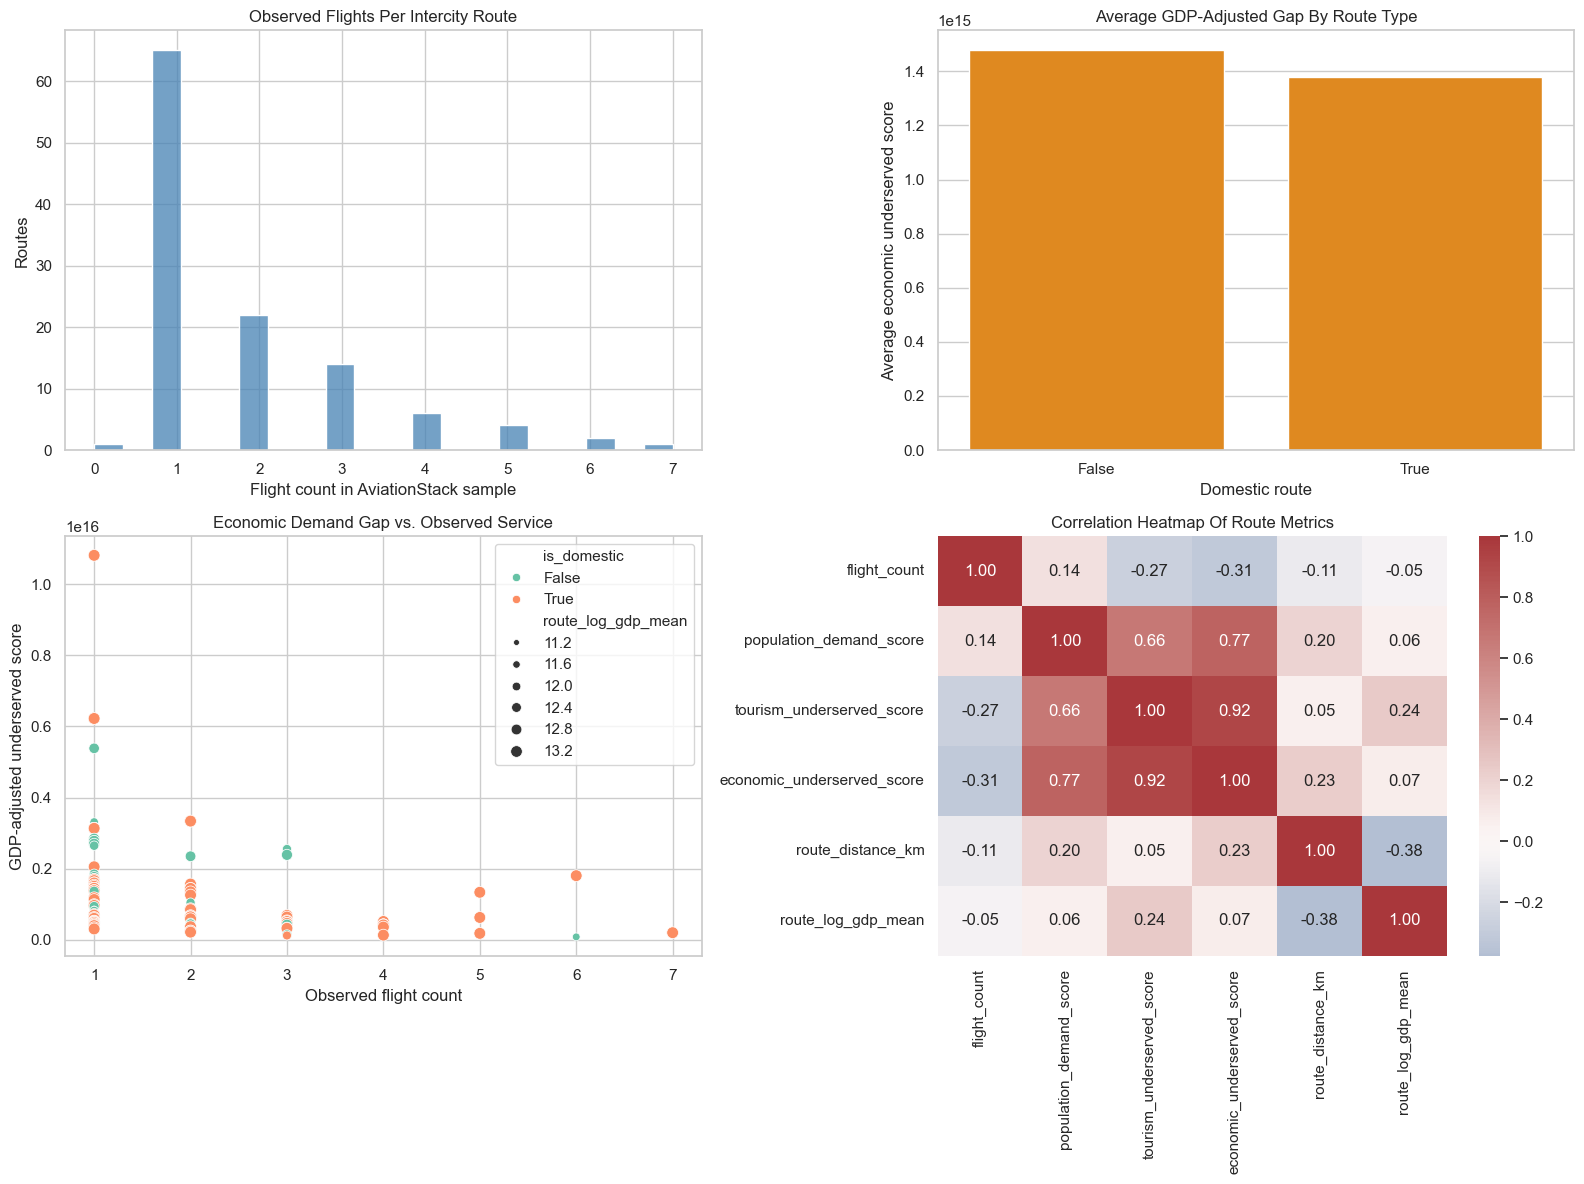

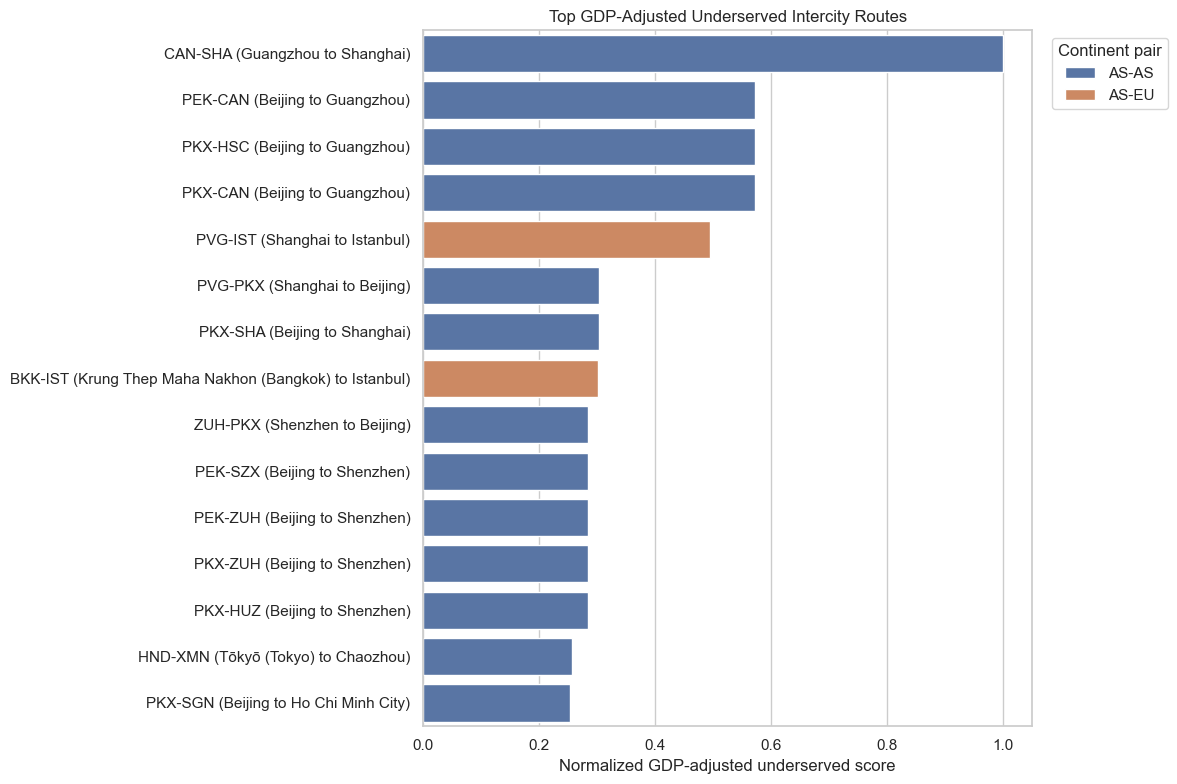

In [6]:
continent_pair_summary = (
    routes.groupby("continent_pair")
    .agg(
        routes=("route", "count"),
        flights=("flight_count", "sum"),
        avg_flight_count=("flight_count", "mean"),
        avg_economic_gap=("economic_underserved_score", "mean"),
        avg_distance_km=("route_distance_km", "mean"),
    )
    .sort_values("avg_economic_gap", ascending=False)
    .reset_index()
)

domestic_summary = (
    routes.groupby("is_domestic")
    .agg(
        routes=("route", "count"),
        flights=("flight_count", "sum"),
        avg_population_gap=("population_underserved_score", "mean"),
        avg_tourism_gap=("tourism_underserved_score", "mean"),
        avg_economic_gap=("economic_underserved_score", "mean"),
    )
    .reset_index()
)

income_pair_summary = (
    routes.groupby(["dep_income_group", "arr_income_group"], dropna=False)
    .agg(
        routes=("route", "count"),
        avg_flight_count=("flight_count", "mean"),
        avg_economic_gap=("economic_underserved_score", "mean"),
    )
    .sort_values("avg_economic_gap", ascending=False)
    .reset_index()
)

score_cols = [
    "flight_count", "population_demand_score", "tourism_underserved_score",
    "economic_underserved_score", "route_distance_km", "route_log_gdp_mean",
]
correlation_data = routes[score_cols].replace([np.inf, -np.inf], np.nan).dropna()

display(continent_pair_summary)
display(domestic_summary)
display(income_pair_summary.head(10))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.histplot(routes["flight_count"], bins=20, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Observed Flights Per Intercity Route")
axes[0, 0].set_xlabel("Flight count in AviationStack sample")
axes[0, 0].set_ylabel("Routes")

sns.barplot(data=domestic_summary, x="is_domestic", y="avg_economic_gap", ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Average GDP-Adjusted Gap By Route Type")
axes[0, 1].set_xlabel("Domestic route")
axes[0, 1].set_ylabel("Average economic underserved score")

sns.scatterplot(
    data=routes,
    x="flight_count",
    y="economic_underserved_score",
    hue="is_domestic",
    size="route_log_gdp_mean",
    ax=axes[1, 0],
    palette="Set2",
)
axes[1, 0].set_title("Economic Demand Gap vs. Observed Service")
axes[1, 0].set_xlabel("Observed flight count")
axes[1, 0].set_ylabel("GDP-adjusted underserved score")

sns.heatmap(correlation_data.corr(), annot=True, cmap="vlag", center=0, fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title("Correlation Heatmap Of Route Metrics")

plt.tight_layout()
plt.show()

plot_top = routes.head(15).copy()
plot_top["label"] = plot_top["route"] + " (" + plot_top["city_pair"] + ")"
plt.figure(figsize=(12, 8))
sns.barplot(data=plot_top, y="label", x="economic_underserved_norm", hue="continent_pair", dodge=False)
plt.title("Top GDP-Adjusted Underserved Intercity Routes")
plt.xlabel("Normalized GDP-adjusted underserved score")
plt.ylabel("")
plt.legend(title="Continent pair", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [7]:
model_features = [
    "dep_city_population", "arr_city_population", "arr_tourism_arrivals", "route_distance_km",
    "dep_log_gdp", "arr_log_gdp", "route_log_gdp_mean", "is_domestic", "continent_pair",
]
model_df = routes[model_features + ["flight_count", "top_economic_gap"]].replace([np.inf, -np.inf], np.nan).dropna().copy()
model_df["is_domestic"] = model_df["is_domestic"].astype(str)

numeric_features = [
    "dep_city_population", "arr_city_population", "arr_tourism_arrivals", "route_distance_km",
    "dep_log_gdp", "arr_log_gdp", "route_log_gdp_mean",
]
categorical_features = ["is_domestic", "continent_pair"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
    ]
)

# Model 1: linear regression for observed route service.
X = model_df[model_features]
y = np.log1p(model_df["flight_count"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
linear_model = Pipeline([("preprocess", preprocess), ("model", LinearRegression())])
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)
linear_metrics = pd.DataFrame({
    "metric": ["R-squared", "RMSE", "MAE", "test rows"],
    "value": [
        r2_score(y_test, y_pred),
        np.sqrt(mean_squared_error(y_test, y_pred)),
        mean_absolute_error(y_test, y_pred),
        len(y_test),
    ],
})

# Model 2: logistic regression for whether a route is in the top economic-gap quartile.
y_class = model_df["top_economic_gap"].astype(int)
stratify_target = y_class if y_class.value_counts().min() >= 2 else None
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.30, random_state=42, stratify=stratify_target
)
logistic_model = Pipeline([("preprocess", preprocess), ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))])
logistic_model.fit(X_train_c, y_train_c)
y_pred_c = logistic_model.predict(X_test_c)
y_proba_c = logistic_model.predict_proba(X_test_c)[:, 1]
roc_auc = roc_auc_score(y_test_c, y_proba_c) if y_test_c.nunique() == 2 else np.nan
logistic_metrics = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "test rows"],
    "value": [
        accuracy_score(y_test_c, y_pred_c),
        precision_score(y_test_c, y_pred_c, zero_division=0),
        recall_score(y_test_c, y_pred_c, zero_division=0),
        f1_score(y_test_c, y_pred_c, zero_division=0),
        roc_auc,
        len(y_test_c),
    ],
})
confusion = pd.DataFrame(
    confusion_matrix(y_test_c, y_pred_c),
    index=["actual_not_top_gap", "actual_top_gap"],
    columns=["pred_not_top_gap", "pred_top_gap"],
)

top_underserved = routes.loc[:, [
    "route", "city_pair", "continent_pair", "is_domestic", "dep_country_name", "arr_country_name",
    "flight_count", "unique_airlines", "route_distance_km", "dep_city_population", "arr_city_population",
    "arr_tourism_arrivals", "arr_gdp_current_usd", "population_underserved_norm",
    "tourism_underserved_norm", "economic_underserved_norm",
]].head(20).copy()
for col in ["dep_city_population", "arr_city_population", "arr_tourism_arrivals", "arr_gdp_current_usd"]:
    top_underserved[col] = top_underserved[col].map(lambda x: f"{x:,.0f}" if pd.notna(x) else "Missing")
for col in ["route_distance_km", "population_underserved_norm", "tourism_underserved_norm", "economic_underserved_norm"]:
    top_underserved[col] = top_underserved[col].round(3)

conn = sqlite3.connect("final_project_routes.sqlite")
try:
    flights_enriched.to_sql("flights_enriched", conn, if_exists="replace", index=False)
    routes.to_sql("routes", conn, if_exists="replace", index=False)
    country_gdp.to_sql("country_gdp", conn, if_exists="replace", index=False)
    tourism.to_sql("tourism", conn, if_exists="replace", index=False)
finally:
    conn.close()

display(linear_metrics)
display(logistic_metrics)
display(confusion)
display(top_underserved)
print("Exported SQLite tables to final_project_routes.sqlite for final_project_sql_queries.sql")

,metric,value
0,R-squared,-0.003863
1,RMSE,0.369437
2,MAE,0.314685
3,test rows,34.000000


,metric,value
0,Accuracy,0.823529
1,Precision,0.800000
2,Recall,0.444444
3,F1,0.571429
4,ROC AUC,0.906667
5,test rows,34.000000


,pred_not_top_gap,pred_top_gap
actual_not_top_gap,24,1
actual_top_gap,5,4


,route,city_pair,continent_pair,is_domestic,dep_country_name,arr_country_name,flight_count,unique_airlines,route_distance_km,dep_city_population,arr_city_population,arr_tourism_arrivals,arr_gdp_current_usd,population_underserved_norm,tourism_underserved_norm,economic_underserved_norm
0,CAN-SHA,Guangzhou to Shanghai,AS-AS,True,China,China,1,1,1175.500,"27,563,372","29,558,908","30,402,000","18,743,803,170,827",1.000,1.000,1.000
1,PEK-CAN,Beijing to Guangzhou,AS-AS,True,China,China,1,1,1880.914,"17,013,303","27,563,372","30,402,000","18,743,803,170,827",0.572,0.575,0.572
2,PKX-HSC,Beijing to Guangzhou,AS-AS,True,China,China,1,1,1638.913,"17,013,303","27,563,372","30,402,000","18,743,803,170,827",0.572,0.575,0.572
3,PKX-CAN,Beijing to Guangzhou,AS-AS,True,China,China,1,1,1815.097,"17,013,303","27,563,372","30,402,000","18,743,803,170,827",0.572,0.575,0.572
4,PVG-IST,Shanghai to Istanbul,AS-EU,False,China,Türkiye,1,1,8021.622,"29,558,908","15,014,763","15,971,000","1,359,123,768,774",0.541,0.285,0.494
5,PVG-PKX,Shanghai to Beijing,AS-AS,True,China,China,2,2,1049.666,"29,558,908","17,013,303","30,402,000","18,743,803,170,827",0.303,0.308,0.303
6,PKX-SHA,Beijing to Shanghai,AS-AS,True,China,China,2,2,1025.011,"17,013,303","29,558,908","30,402,000","18,743,803,170,827",0.303,0.308,0.303
7,BKK-IST,Krung Thep Maha Nakhon (Bangkok) to Istanbul,AS-EU,False,Thailand,Türkiye,1,1,7513.835,"18,180,280","15,014,763","15,971,000","1,359,123,768,774",0.329,0.175,0.301
8,ZUH-PKX,Shenzhen to Beijing,AS-AS,True,China,China,1,1,1966.538,"13,878,396","17,013,303","30,402,000","18,743,803,170,827",0.284,0.289,0.284
9,PEK-SZX,Beijing to Shenzhen,AS-AS,True,China,China,1,1,1956.765,"17,013,303","13,878,396","30,402,000","18,743,803,170,827",0.284,0.289,0.284


Exported SQLite tables to final_project_routes.sqlite for final_project_sql_queries.sql


## Conclusion

This final analysis extends the midterm route-screening tool by adding country-level GDP to the original population and tourism view of demand. The result is a ranked list of intercity routes where observed flight supply is low relative to large connected city populations, destination tourism demand, and destination-country economic capacity.

For airline route planners, the `top_underserved` table should be treated as a screening list rather than a launch recommendation. Routes near the top deserve deeper commercial review because they combine large city markets with limited observed service in the AviationStack sample. The domestic/cross-border split matters because regulatory approvals, airport slots, bilateral agreements, and sales strategy differ across those route types.

The GDP-adjusted score adds a useful business-travel and purchasing-power lens, but it is intentionally based on log GDP so that the largest economies do not automatically dominate the ranking. The models are included as diagnostic tools: the linear model tests whether the engineered demand variables explain observed service, while the logistic model tests whether the same features can identify top-quartile underserved routes. Because the logistic target is derived from the same scoring framework, its metrics should be read as a diagnostic validation exercise rather than an independent forecast.

Key limitations remain. The AviationStack sample is not a full-year schedule, the WUP city file covers only the top 100 cities, and tourism/GDP are country-level proxies rather than city-level measures. With more time, the next datasets to add would be full-year scheduled capacity, historical passenger traffic, airport slot constraints, visa restrictions, and city-level business travel or tourism measures.